# Division, entrenamiento y comparación de modelos

Esta notebook contiene la etapa de modelado y evaluación del sistema predictivo de informalidad laboral. A partir del conjunto de datos previamente preparado, se realizará la división entrenamiento-prueba, el preprocesamiento mediante pipelines, el tratamiento de valores faltantes, la codificación de variables categóricas, la validación cruzada y la comparación de distintos modelos. La evaluación considerará tanto métricas individuales como métricas ponderadas mediante FAC_TRI, manteniendo el conjunto de prueba reservado para la evaluación final.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn as sk

In [2]:
df = pd.read_csv("/home/jeffrey/Documentos/Proyectos/enoe_informalidad/data/processed/df_modelado_final.csv")

variables_finales = [
    "EDA",
    "ANTIGUEDAD",
    "PAR_C_GRUPO",
    "ESCOLARIDAD_GRUPO",
    "INGRESO_GRUPO",
    "DURACION_GRUPO",
    "TAMANO_LOCALIDAD",
    "ESTADO_CONYUGAL",
    "BUSQUEDA_OTRO_EMPLEO",
    "TIENE_JEFE",
    "SEXO",
    "ENTIDAD"
]

X_modelo = df[variables_finales].copy()
y = df["EMP_PPAL"].copy()
pesos = df["FAC_TRI"].copy()


### Division del dataset
Dividamos el dataset en entrenamiento y prueba (la validación se hará con cross-validation)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, pesos_train, pesos_test = train_test_split(
    X_modelo,
    y,
    pesos,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verifiquemos sus formas y distribuciones
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))
print(pesos_train.shape, pesos_test.shape)

(150045, 12) (37512, 12)
EMP_PPAL
1    0.517598
0    0.482402
Name: proportion, dtype: float64
EMP_PPAL
1    0.517594
0    0.482406
Name: proportion, dtype: float64
(150045,) (37512,)


Ahora realizamos dos pipelines, uno para variables numéricas (EDA y ANTIGUEDAD) y otro para variables categóricas. Para las numéricas simplemente imputaremos la mediana para la variable ANTIGUEDAD donde los valores sean nulos, mientras que para las categóricas haremos un OneHotEncoder

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

variables_numericas = ["EDA", "ANTIGUEDAD"]

variables_categoricas = [
    "PAR_C_GRUPO",
    "ESCOLARIDAD_GRUPO",
    "INGRESO_GRUPO",
    "DURACION_GRUPO",
    "TAMANO_LOCALIDAD",
    "ESTADO_CONYUGAL",
    "BUSQUEDA_OTRO_EMPLEO",
    "TIENE_JEFE",
    "SEXO",
    "ENTIDAD"
]

pipeline_numerico = Pipeline([
    (
        "imputador",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

pipeline_categorico = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocesador = ColumnTransformer([
    ("numericas", pipeline_numerico, variables_numericas),
    ("categoricas", pipeline_categorico, variables_categoricas)
])

Ahora proponemos como primer modelo el modelo de regresión logística, ya que permitirá entregar probabilidades directamente y sirve como buena linea base. 

In [5]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000))
])

Las métricas que usaremos para validar el modelo serán las siguientes
+ ROC-AUC: capacidad de ordenar informales por mayor riesgo.
+ Log-loss: calidad de las probabilidades.
+ Brier score: calibración/error probabilístico.

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = {
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
    "neg_brier": "neg_brier_score"
}

resultados_cv = cross_validate(
    modelo_logistico,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    n_jobs=-1
)

print("ROC-AUC:")
print(resultados_cv["test_roc_auc"].mean())
print(resultados_cv["test_roc_auc"].std())

print("\nLog-loss:")
print(-resultados_cv["test_neg_log_loss"].mean())
print(resultados_cv["test_neg_log_loss"].std())

print("\nBrier score:")
print(-resultados_cv["test_neg_brier"].mean())
print(resultados_cv["test_neg_brier"].std())

ROC-AUC:
0.8608920690523295
0.0008874380021156499

Log-loss:
0.46547859118530244
0.0008021471059918981

Brier score:
0.1515416170285445
0.0005269117609702689


La regresión logística obtuvo un ROC-AUC medio de 0.8609, lo que indica una buena capacidad para discriminar entre empleo informal y formal. El Log-loss de 0.4655 y el Brier score de 0.1515 muestran un desempeño probabilístico razonable para un modelo baseline. Además, la baja variabilidad entre folds sugiere que el rendimiento es estable. 

Como siguiente paso, se evaluará el mismo modelo incorporando `FAC_TRI` como peso muestral para analizar si la ponderación de la ENOE modifica los resultados. Cabe mencionar que `FAC_TRI` se utiliza para entrenar la regresión logística, pero estas métricas siguen calculándose sin ponderar. Esto nos permite contestar primero una pregunta:

¿Cambia el desempeño sobre individuos cuando el modelo aprende dando a cada registro la representatividad poblacional definida por ENOE?

In [7]:
resultados_cv_ponderado = cross_validate(
    modelo_logistico,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    params={
        "modelo__sample_weight": pesos_train
    },
    n_jobs=-1
)

print("ROC-AUC:")
print(resultados_cv_ponderado["test_roc_auc"].mean())
print(resultados_cv_ponderado["test_roc_auc"].std())

print("\nLog-loss:")
print(-resultados_cv_ponderado["test_neg_log_loss"].mean())
print(resultados_cv_ponderado["test_neg_log_loss"].std())

print("\nBrier score:")
print(-resultados_cv_ponderado["test_neg_brier"].mean())
print(resultados_cv_ponderado["test_neg_brier"].std())

ROC-AUC:
0.8600663139596987
0.0011392139062726574

Log-loss:
0.46663726098715824
0.001066326766275767

Brier score:
0.15196059692808625
0.0006895207413092409


La incorporación de `FAC_TRI` como peso de entrenamiento produjo resultados muy similares al modelo no ponderado, con una ligera disminución en las métricas de validación. Esto indica que la ponderación muestral no modifica sustancialmente el desempeño predictivo individual del modelo. No obstante, dado que el objetivo tiene una interpretación poblacional, se mantendrá la ponderación como alternativa relevante y se evaluarán también métricas ponderadas.

Entrenemos ahora dos modelos, mismo StratifiedKFold, una sin pesos y otra con FAC_TRI y evaluemos ambas usando métricas ponderadas con los pesos del fold de la validación

In [8]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import numpy as np

resultados_no_ponderado = {
    "roc_auc": [],
    "log_loss": [],
    "brier": []
}

resultados_ponderado = {
    "roc_auc": [],
    "log_loss": [],
    "brier": []
}

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    w_tr = pesos_train.iloc[train_idx]
    w_val = pesos_train.iloc[val_idx]

    # Modelo entrenado sin ponderación
    modelo_np = clone(modelo_logistico)
    modelo_np.fit(X_tr, y_tr)

    prob_np = modelo_np.predict_proba(X_val)[:, 1]

    resultados_no_ponderado["roc_auc"].append(
        roc_auc_score(y_val, prob_np, sample_weight=w_val)
    )
    resultados_no_ponderado["log_loss"].append(
        log_loss(y_val, prob_np, sample_weight=w_val)
    )
    resultados_no_ponderado["brier"].append(
        brier_score_loss(y_val, prob_np, sample_weight=w_val)
    )

    # Modelo entrenado con FAC_TRI
    modelo_p = clone(modelo_logistico)
    modelo_p.fit(
        X_tr,
        y_tr,
        modelo__sample_weight=w_tr
    )

    prob_p = modelo_p.predict_proba(X_val)[:, 1]

    resultados_ponderado["roc_auc"].append(
        roc_auc_score(y_val, prob_p, sample_weight=w_val)
    )
    resultados_ponderado["log_loss"].append(
        log_loss(y_val, prob_p, sample_weight=w_val)
    )
    resultados_ponderado["brier"].append(
        brier_score_loss(y_val, prob_p, sample_weight=w_val)
    )
    
for nombre, resultados in [
    ("Sin ponderar entrenamiento", resultados_no_ponderado),
    ("Ponderado entrenamiento", resultados_ponderado)
]:
    print(f"\n{nombre}")

    for metrica, valores in resultados.items():
        print(
            f"{metrica}: "
            f"{np.mean(valores):.4f} ± {np.std(valores):.4f}"
        )


Sin ponderar entrenamiento
roc_auc: 0.8646 ± 0.0018
log_loss: 0.4599 ± 0.0025
brier: 0.1488 ± 0.0009

Ponderado entrenamiento
roc_auc: 0.8648 ± 0.0017
log_loss: 0.4593 ± 0.0023
brier: 0.1486 ± 0.0008


Al evaluar ambos modelos mediante métricas ponderadas por `FAC_TRI`, el modelo entrenado con ponderación obtuvo una mejora ligera y consistente en ROC-AUC, Log-loss y Brier score. Aunque las diferencias son reducidas, el uso de los factores de expansión resulta coherente con el objetivo poblacional del proyecto. Por ello, se conservará la versión ponderada de la regresión logística como baseline principal.

Compararemos esta baseline con un modelo no lineal, ya que, como observamos en el análisis de EDA y ANTIGUEDAD, estas variables no fueron lineales. Probemos un modelo como randomforest

In [9]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

resultados_rf = {
    "roc_auc": [],
    "log_loss": [],
    "brier": []
}

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    w_tr = pesos_train.iloc[train_idx]
    w_val = pesos_train.iloc[val_idx]

    modelo = clone(modelo_rf)

    modelo.fit(
        X_tr,
        y_tr,
        modelo__sample_weight=w_tr
    )

    probabilidades = modelo.predict_proba(X_val)[:, 1]

    resultados_rf["roc_auc"].append(
        roc_auc_score(y_val, probabilidades, sample_weight=w_val)
    )

    resultados_rf["log_loss"].append(
        log_loss(y_val, probabilidades, sample_weight=w_val)
    )

    resultados_rf["brier"].append(
        brier_score_loss(y_val, probabilidades, sample_weight=w_val)
    )
    
for metrica, valores in resultados_rf.items():
    print(
        f"{metrica}: "
        f"{np.mean(valores):.4f} ± {np.std(valores):.4f}"
    )


roc_auc: 0.8616 ± 0.0020
log_loss: 0.4731 ± 0.0052
brier: 0.1508 ± 0.0011


El Random Forest no mejoró el baseline de regresión logística. Obtuvo menor ROC-AUC y mayores valores de Log-loss y Brier score, además de requerir un tiempo de entrenamiento considerablemente mayor. Por tanto, no se justifica preferirlo en su configuración actual. La regresión logística ponderada continúa como baseline principal.

Ahora probaremos Gradient Boosting, concretamente, HistGradientBoostingClassifier, que suele ser bastante más eficiente que Random Forest.

Actualmente el OneHotEncoder produce una matriz sparse, mientras que HistGradientBoostingClassifier necesita entrada densa. Por eso conviene crear un preprocesador específico cambiando sparse_output=False.

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier

pipeline_categorico_hgb = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocesador_hgb = ColumnTransformer([
    ("numericas", pipeline_numerico, variables_numericas),
    ("categoricas", pipeline_categorico_hgb, variables_categoricas)
])

modelo_hgb = Pipeline([
    ("preprocesador", preprocesador_hgb),
    (
        "modelo",
        HistGradientBoostingClassifier(
            random_state=42
        )
    )
])

resultados_hgb = {
    "roc_auc": [],
    "log_loss": [],
    "brier": []
}

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    w_tr = pesos_train.iloc[train_idx]
    w_val = pesos_train.iloc[val_idx]

    modelo = clone(modelo_hgb)

    modelo.fit(
        X_tr,
        y_tr,
        modelo__sample_weight=w_tr
    )

    probabilidades = modelo.predict_proba(X_val)[:, 1]

    resultados_hgb["roc_auc"].append(
        roc_auc_score(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    resultados_hgb["log_loss"].append(
        log_loss(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    resultados_hgb["brier"].append(
        brier_score_loss(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )
    
for metrica, valores in resultados_hgb.items():
    print(
        f"{metrica}: "
        f"{np.mean(valores):.4f} ± {np.std(valores):.4f}"
    )

roc_auc: 0.8790 ± 0.0009
log_loss: 0.4342 ± 0.0009
brier: 0.1402 ± 0.0004


HistGradientBoostingClassifier obtuvo el mejor desempeño entre los modelos evaluados, superando tanto a la regresión logística como a Random Forest en ROC-AUC, Log-loss y Brier score bajo validación cruzada ponderada. Esto sugiere que existen relaciones no lineales e interacciones relevantes entre los predictores. Por tanto, se selecciona provisionalmente como el principal candidato para continuar la fase de modelado.

Respondamos ahora:

**De toda la población informal representada en el fold, ¿qué porcentaje está dentro del 20% de población al que el modelo asignó mayor riesgo?**

In [11]:
resultados_hgb = {
    "roc_auc": [],
    "log_loss": [],
    "brier": [],
    "captura_top20": []
}

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    w_tr = pesos_train.iloc[train_idx]
    w_val = pesos_train.iloc[val_idx]

    modelo = clone(modelo_hgb)

    modelo.fit(
        X_tr,
        y_tr,
        modelo__sample_weight=w_tr
    )

    probabilidades = modelo.predict_proba(X_val)[:, 1]

    # Métricas probabilísticas
    resultados_hgb["roc_auc"].append(
        roc_auc_score(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    resultados_hgb["log_loss"].append(
        log_loss(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    resultados_hgb["brier"].append(
        brier_score_loss(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    # --------------------------------
    # Captura de informales en top 20%
    # --------------------------------

    df_val = pd.DataFrame({
        "y": y_val.to_numpy(),
        "probabilidad": probabilidades,
        "peso": w_val.to_numpy()
    })

    # Ordenar de mayor a menor riesgo
    df_val = df_val.sort_values(
        "probabilidad",
        ascending=False
    )

    # Población acumulada representada
    df_val["peso_acumulado"] = df_val["peso"].cumsum()

    limite_20 = 0.20 * df_val["peso"].sum()

    top20 = df_val[
        df_val["peso_acumulado"] <= limite_20
    ]

    # Informales poblacionales dentro del top 20%
    informales_top20 = (
        top20["y"] * top20["peso"]
    ).sum()

    # Total de informales poblacionales del fold
    informales_totales = (
        df_val["y"] * df_val["peso"]
    ).sum()

    captura = informales_top20 / informales_totales

    resultados_hgb["captura_top20"].append(captura)
    
for metrica, valores in resultados_hgb.items():
    print(
        f"{metrica}: "
        f"{np.mean(valores):.4f} ± {np.std(valores):.4f}"
    )
    
captura_media = np.mean(resultados_hgb["captura_top20"])

lift_top20 = captura_media / 0.20

print(f"Captura top 20%: {captura_media:.2%}")
print(f"Lift top 20%: {lift_top20:.2f}x")

roc_auc: 0.8790 ± 0.0009
log_loss: 0.4342 ± 0.0009
brier: 0.1402 ± 0.0004
captura_top20: 0.3505 ± 0.0029
Captura top 20%: 35.05%
Lift top 20%: 1.75x


El 20% de la población con mayor riesgo estimado concentra, en promedio, el 35.05% de la población informal, equivalente a un lift de 1.75 respecto de una selección aleatoria. 

<!-- El resultado muestra capacidad útil de priorización, aunque no alcanza el objetivo aspiracional inicial de concentrar aproximadamente el 50% de los trabajadores informales. -->

Comparemos si estos resultados son mejores o menores en el modelo de regresión logistica

In [12]:
resultados_log = {
    "roc_auc": [],
    "log_loss": [],
    "brier": [],
    "captura_top20": []
}

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    w_tr = pesos_train.iloc[train_idx]
    w_val = pesos_train.iloc[val_idx]

    modelo = clone(modelo_logistico)

    modelo.fit(
        X_tr,
        y_tr,
        modelo__sample_weight=w_tr
    )

    probabilidades = modelo.predict_proba(X_val)[:, 1]

    # Métricas probabilísticas
    resultados_log["roc_auc"].append(
        roc_auc_score(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    resultados_log["log_loss"].append(
        log_loss(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    resultados_log["brier"].append(
        brier_score_loss(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    # --------------------------------
    # Captura de informales en top 20%
    # --------------------------------

    df_val = pd.DataFrame({
        "y": y_val.to_numpy(),
        "probabilidad": probabilidades,
        "peso": w_val.to_numpy()
    })

    # Ordenar de mayor a menor riesgo
    df_val = df_val.sort_values(
        "probabilidad",
        ascending=False
    )

    # Población acumulada representada
    df_val["peso_acumulado"] = df_val["peso"].cumsum()

    limite_20 = 0.20 * df_val["peso"].sum()

    top20 = df_val[
        df_val["peso_acumulado"] <= limite_20
    ]

    # Informales poblacionales dentro del top 20%
    informales_top20 = (
        top20["y"] * top20["peso"]
    ).sum()

    # Total de informales poblacionales del fold
    informales_totales = (
        df_val["y"] * df_val["peso"]
    ).sum()

    captura = informales_top20 / informales_totales

    resultados_log["captura_top20"].append(captura)
    
for metrica, valores in resultados_log.items():
    print(
        f"{metrica}: "
        f"{np.mean(valores):.4f} ± {np.std(valores):.4f}"
    )
    
captura_media = np.mean(resultados_log["captura_top20"])

lift_top20 = captura_media / 0.20

print(f"Captura top 20%: {captura_media:.2%}")
print(f"Lift top 20%: {lift_top20:.2f}x")

roc_auc: 0.8648 ± 0.0017
log_loss: 0.4593 ± 0.0023
brier: 0.1486 ± 0.0008
captura_top20: 0.3455 ± 0.0033
Captura top 20%: 34.55%
Lift top 20%: 1.73x


HistGradientBoostingClassifier también presentó el mejor desempeño operativo, capturando el 35.05% de la población informal dentro del 20% con mayor riesgo, frente al 34.55% de la regresión logística. Sin embargo, la mejora en esta métrica es moderada y ambos modelos permanecen por debajo del objetivo aspiracional del 50%.

El paso siguiente será hacer un ajuste leve de hiperparámetros con el objetivo de ver si el modelo HGB base puede mejorar de forma real sin disprar complejidad ni tiempo. Haremos la busqueda de los mejores hiperparámetros dentro de la siguiente lista, utilizando RandomizedSearchCV con 15 combinaciones, más que nada por cuestion de tiempo computo.

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "modelo__learning_rate": [0.05, 0.1],
    "modelo__max_iter": [100, 200],
    "modelo__max_leaf_nodes": [15, 31],
    "modelo__min_samples_leaf": [20, 50],
    "modelo__l2_regularization": [0.0, 1.0]
}

param_distributions = {
    "modelo__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "modelo__max_iter": [100, 150, 200, 300],
    "modelo__max_leaf_nodes": [15, 31, 63],
    "modelo__min_samples_leaf": [20, 40, 80],
    "modelo__l2_regularization": [0.0, 0.5, 1.0, 2.0]
}

busqueda_hgb = RandomizedSearchCV(
    estimator=modelo_hgb,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busqueda_hgb.fit(
    X_train,
    y_train,
    modelo__sample_weight=pesos_train
)
print("Mejores parámetros:")
print(busqueda_hgb.best_params_)

print("\nMejor ROC-AUC CV:")
print(busqueda_hgb.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejores parámetros:
{'modelo__min_samples_leaf': 80, 'modelo__max_leaf_nodes': 31, 'modelo__max_iter': 300, 'modelo__learning_rate': 0.05, 'modelo__l2_regularization': 1.0}

Mejor ROC-AUC CV:
0.8761534612774005


0.87615 no debe compararse directamente con nuestro 0.8790, porque ese best_score_ proviene del scoring="roc_auc" no ponderado de RandomizedSearchCV.

REpitamos nuestro CV manual usando esos parámetros y evaluando con FAC_TRI

In [14]:
modelo_hgb_tuned = Pipeline([
    ("preprocesador", preprocesador_hgb),
    (
        "modelo",
        HistGradientBoostingClassifier(
            min_samples_leaf=80,
            max_leaf_nodes=31,
            max_iter=300,
            learning_rate=0.05,
            l2_regularization=1.0,
            random_state=42
        )
    )
])

resultados_hgb_tuned = {
    "roc_auc": [],
    "log_loss": [],
    "brier": [],
    "captura_top20": []
}

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    w_tr = pesos_train.iloc[train_idx]
    w_val = pesos_train.iloc[val_idx]

    modelo = clone(modelo_hgb_tuned)

    modelo.fit(
        X_tr,
        y_tr,
        modelo__sample_weight=w_tr
    )

    probabilidades = modelo.predict_proba(X_val)[:, 1]

    resultados_hgb_tuned["roc_auc"].append(
        roc_auc_score(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    resultados_hgb_tuned["log_loss"].append(
        log_loss(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    resultados_hgb_tuned["brier"].append(
        brier_score_loss(
            y_val,
            probabilidades,
            sample_weight=w_val
        )
    )

    # Captura top 20%
    df_val = pd.DataFrame({
        "y": y_val.to_numpy(),
        "probabilidad": probabilidades,
        "peso": w_val.to_numpy()
    })

    df_val = df_val.sort_values(
        "probabilidad",
        ascending=False
    )

    df_val["peso_acumulado"] = df_val["peso"].cumsum()

    limite_20 = 0.20 * df_val["peso"].sum()

    top20 = df_val[
        df_val["peso_acumulado"] <= limite_20
    ]

    informales_top20 = (
        top20["y"] * top20["peso"]
    ).sum()

    informales_totales = (
        df_val["y"] * df_val["peso"]
    ).sum()

    resultados_hgb_tuned["captura_top20"].append(
        informales_top20 / informales_totales
    )

for metrica, valores in resultados_hgb_tuned.items():
    print(
        f"{metrica}: "
        f"{np.mean(valores):.4f} ± {np.std(valores):.4f}"
    )

captura_media = np.mean(
    resultados_hgb_tuned["captura_top20"]
)

print(f"Captura top 20%: {captura_media:.2%}")
print(f"Lift top 20%: {captura_media / 0.20:.2f}x")

roc_auc: 0.8797 ± 0.0009
log_loss: 0.4332 ± 0.0009
brier: 0.1399 ± 0.0004
captura_top20: 0.3505 ± 0.0031
Captura top 20%: 35.05%
Lift top 20%: 1.75x


El tuning mejora marginalmente discriminación y calidad probabilística, pero no mejora en absoluto la utilidad operativa top-20%. Se conservará el HGB tuneado como candidato final porque las mejoras son consistentes y la configuración sigue siendo razonable.

Los parámetros finales candidatos quedarían:

HistGradientBoostingClassifier(
    min_samples_leaf=80,
    max_leaf_nodes=31,
    max_iter=300,
    learning_rate=0.05,
    l2_regularization=1.0,
    random_state=42
)

Ahora estudiaremos la calibración de las probabilidades del HGB tuneado. Esto es importante porque nuestro producto no solo quiere ordenar personas, sino reportar una probabilidad interpretable de informalidad.

Una probabilidad está bien calibrada si, por ejemplo, entre las personas a las que el modelo asigna alrededor de 70% de riesgo, aproximadamente 70% realmente son informales. La curva de calibración compara probabilidad predicha vs. frecuencia observada.

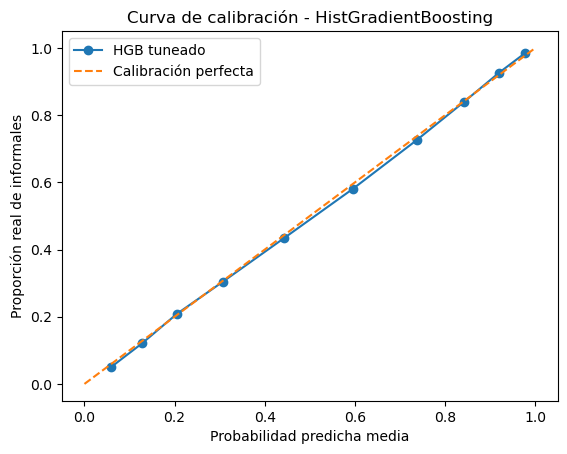

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.calibration import calibration_curve

probabilidades_cv = cross_val_predict(
    modelo_hgb_tuned,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    params={
        "modelo__sample_weight": pesos_train
    },
    n_jobs=-1
)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_train,
    probabilidades_cv,
    n_bins=10,
    strategy="quantile"
)

plt.plot(prob_pred, prob_true, marker="o", label="HGB tuneado")
plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")

plt.xlabel("Probabilidad predicha media")
plt.ylabel("Proporción real de informales")
plt.title("Curva de calibración - HistGradientBoosting")
plt.legend()
plt.show()

La curva de calibración del HistGradientBoostingClassifier tuneado se mantiene muy próxima a la diagonal de calibración perfecta en prácticamente todo el rango de probabilidades. Esto indica que las probabilidades estimadas por el modelo son consistentes con las frecuencias observadas de informalidad. Se aprecian únicamente desviaciones pequeñas en algunos intervalos intermedios y altos, sin un patrón severo de sobreestimación o subestimación. El modelo presenta una calibración visualmente buena, por lo que no hay evidencia clara de que sea necesario aplicar una calibración adicional en esta etapa. 

Esta evaluación es una primera revisión no ponderada; dado que el análisis del proyecto utiliza FAC_TRI, conviene complementar posteriormente con una curva de calibración ponderada antes de cerrar la decisión. Construyamos esa curva ponderada

/tmp/ipykernel_7689/2983167809.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


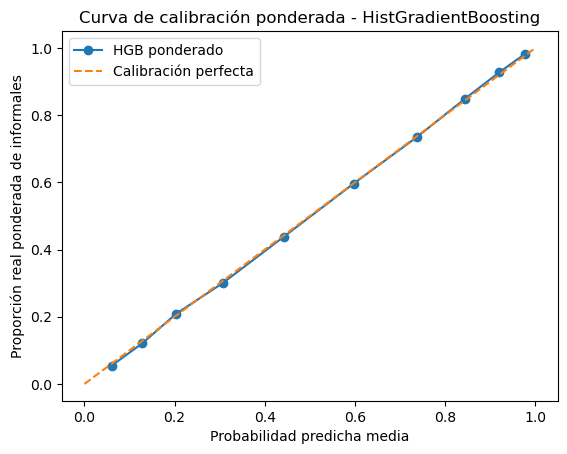

In [16]:
df_calibracion = pd.DataFrame({
    "y": y_train.to_numpy(),
    "probabilidad": probabilidades_cv,
    "peso": pesos_train.to_numpy()
})

df_calibracion["bin"] = pd.qcut(
    df_calibracion["probabilidad"],
    q=10,
    duplicates="drop"
)

calibracion_ponderada = (
    df_calibracion
    .groupby("bin", observed=True)
    .apply(
        lambda g: pd.Series({
            "prob_pred_media": np.average(
                g["probabilidad"],
                weights=g["peso"]
            ),
            "prop_real_informal": np.average(
                g["y"],
                weights=g["peso"]
            )
        })
    )
    .reset_index(drop=True)
)
plt.plot(
    calibracion_ponderada["prob_pred_media"],
    calibracion_ponderada["prop_real_informal"],
    marker="o",
    label="HGB ponderado"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración perfecta"
)

plt.xlabel("Probabilidad predicha media")
plt.ylabel("Proporción real ponderada de informales")
plt.title("Curva de calibración ponderada - HistGradientBoosting")
plt.legend()
plt.show()

La curva de calibración ponderada por FAC_TRI se mantiene prácticamente sobre la diagonal de calibración perfecta a lo largo de todo el rango de probabilidades. Esto indica que las probabilidades estimadas por el HistGradientBoostingClassifier son consistentes con la proporción poblacional observada de informalidad.

La evaluación final del modelo se realizará exclusivamente sobre el conjunto de pruba. Las métricas, y su interpretación, serán las siguientes

1. ROC-AUC: Mide capacidad de ranking/discriminación. Cuanto mayor, mejor.
2. Log-loss: Evalúa la calidad de las probabilidades y penaliza errores muy seguros. Cuanto menor, mejor.
3. Brier score: Mide el error cuadrático de las probabilidades predichas frente al resultado real.Cuanto menor, mejor.
4. Captura Top 20%: De todos los informales representados en la población, qué porcentaje está dentro del 20% con mayor riesgo predicho. Cuanto mayor, mejor.
5. Lift Top 20%: Compara esa captura contra una selección aleatoria del 20%. lift = captura_top20 / 0.20

Como referencia, tenemos los resultados de CV del HGB tuneado

ROC-AUC:        0.8797 ± 0.0009

Log-loss:       0.4332 ± 0.0009

Brier:          0.1399 ± 0.0004

Captura Top20:  35.05% ± 0.31 pp

Lift Top20:     1.75x

Entrenemos entonces modelo_hgb_tuned con todo X_train y evaluemoslo con X_test

In [17]:
# Entrenamiento final con todo el conjunto de entrenamiento
modelo_final = clone(modelo_hgb_tuned)

modelo_final.fit(
    X_train,
    y_train,
    modelo__sample_weight=pesos_train
)

# Probabilidades sobre test
prob_test = modelo_final.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(
    y_test,
    prob_test,
    sample_weight=pesos_test
)

log_loss_test = log_loss(
    y_test,
    prob_test,
    sample_weight=pesos_test
)

brier_test = brier_score_loss(
    y_test,
    prob_test,
    sample_weight=pesos_test
)

df_test_eval = pd.DataFrame({
    "y": y_test.to_numpy(),
    "probabilidad": prob_test,
    "peso": pesos_test.to_numpy()
})

df_test_eval = df_test_eval.sort_values(
    "probabilidad",
    ascending=False
)

df_test_eval["peso_acumulado"] = (
    df_test_eval["peso"].cumsum()
)

limite_20 = 0.20 * df_test_eval["peso"].sum()

top20_test = df_test_eval[
    df_test_eval["peso_acumulado"] <= limite_20
]

informales_top20_test = (
    top20_test["y"] * top20_test["peso"]
).sum()

informales_totales_test = (
    df_test_eval["y"] * df_test_eval["peso"]
).sum()

captura_top20_test = (
    informales_top20_test / informales_totales_test
)

lift_top20_test = captura_top20_test / 0.20

print(f"ROC-AUC: {roc_auc_test:.4f}")
print(f"Log-loss: {log_loss_test:.4f}")
print(f"Brier: {brier_test:.4f}")
print(f"Captura Top 20%: {captura_top20_test:.2%}")
print(f"Lift Top 20%: {lift_top20_test:.2f}x")

ROC-AUC: 0.8761
Log-loss: 0.4383
Brier: 0.1423
Captura Top 20%: 35.15%
Lift Top 20%: 1.76x


La evaluación final sobre el conjunto de prueba mostró un desempeño consistente con los resultados obtenidos mediante validación cruzada. El modelo alcanzó un ROC-AUC de 0.8761, Log-loss de 0.4383 y Brier score de 0.1423. Además, el 20% de la población con mayor riesgo estimado concentró el 35.15% de la población informal, equivalente a un lift de 1.76 respecto de una selección aleatoria. La proximidad entre los resultados de validación cruzada y prueba sugiere una adecuada capacidad de generalización y ausencia de un deterioro relevante fuera de muestra.

# Explicabilidad

Con el modelo ya definido y evaluado, el siguiente paso será responder la pregunta: ¿cuánto empeora el desempeño del modelo si destruyo la información de una variable?

La idea es:

1. Calculamos una métrica del modelo normalmente.
2. Elegimos una variable, por ejemplo INGRESO_GRUPO.
3. Barajamos aleatoriamente sus valores entre personas, rompiendo su relación con el objetivo.
4. Volvemos a calcular la métrica.
5. Si el desempeño cae mucho, esa variable era importante para las predicciones.

Usaremos el conjuntto X_test ya que se debe calcular sobre datos que el modelo no haya usado para ajustar sus parámetros. Veamos la tabla para cada variable y su gráfica

In [18]:
from sklearn.inspection import permutation_importance

resultado_perm = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    sample_weight=pesos_test
)

tabla_importancias = pd.DataFrame({
    "variable": X_test.columns,
    "importancia_media": resultado_perm.importances_mean,
    "desviacion": resultado_perm.importances_std
})

tabla_importancias = (
    tabla_importancias
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)

tabla_importancias

,variable,importancia_media,desviacion
0,INGRESO_GRUPO,0.066052,0.001519
1,TIENE_JEFE,0.061110,0.001728
2,ESCOLARIDAD_GRUPO,0.052800,0.001573
3,DURACION_GRUPO,0.040175,0.002217
4,ENTIDAD,0.018852,0.000775
5,EDA,0.017356,0.000998
6,ANTIGUEDAD,0.015111,0.000491
7,TAMANO_LOCALIDAD,0.011565,0.000679
8,SEXO,0.001546,0.000237
9,ESTADO_CONYUGAL,0.000806,0.000170


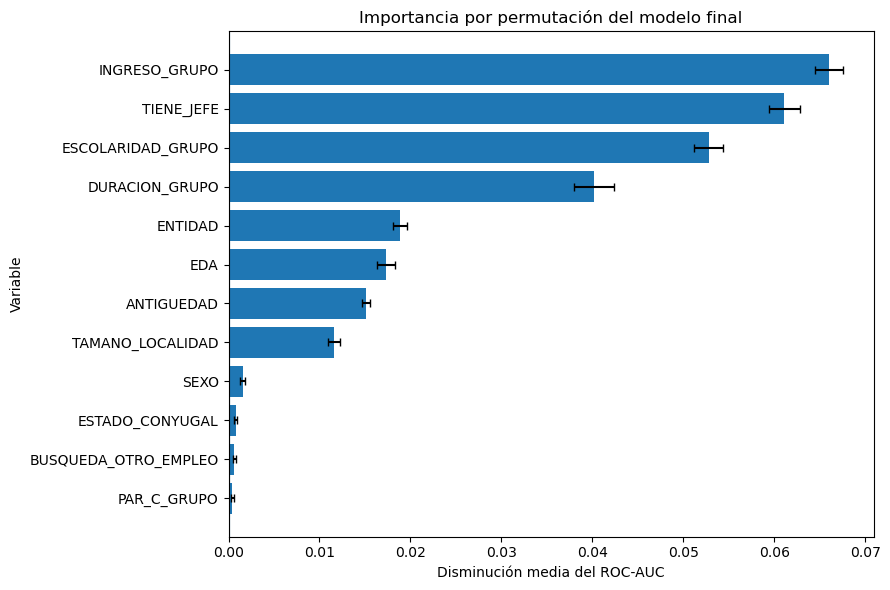

In [19]:
import matplotlib.pyplot as plt

tabla_grafica = tabla_importancias.sort_values(
    "importancia_media",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    tabla_grafica["variable"],
    tabla_grafica["importancia_media"],
    xerr=tabla_grafica["desviacion"],
    capsize=3
)

plt.xlabel("Disminución media del ROC-AUC")
plt.ylabel("Variable")
plt.title("Importancia por permutación del modelo final")
plt.axvline(0, linewidth=0.8)
plt.tight_layout()

plt.show()

La importancia por permutación muestra que el ingreso, la existencia de un jefe, la escolaridad y la duración de la jornada concentran la mayor contribución a la capacidad discriminativa del modelo. Al permutar estas variables se observa la mayor reducción del ROC-AUC. En contraste, sexo, estado conyugal, búsqueda de otro empleo y relación de parentesco presentan una contribución marginal al desempeño global. Las reducidas barras de variabilidad sugieren que estas estimaciones son estables entre las distintas permutaciones. Estas importancias reflejan relevancia predictiva dentro del modelo y no deben interpretarse como efectos causales.

Pasemos ahora con SHAP. Con SHAP no solo sabremos qué variables importan, sino también cómo empujan cada predicción hacia mayor o menor riesgo de informalidad. SHAP está basado en valores de Shapley y TreeExplainer está diseñado específicamente para modelos basados en árboles; además, SHAP incluye soporte para HistGradientBoosting de scikit-learn.

Para nuestro caso, no conviene pasar directamente el Pipeline completo a TreeExplainer. Primero transformaremos X_test con el preprocesador ya ajustado y después explicaremos únicamente el HistGradientBoostingClassifier.

Antes de calcular SHAP necesitamos comprobar cuántas columnas resultaron después del preprocesamiento, porque las 12 variables originales se habrán convertido en muchas características debido al One-Hot Encoding.

In [20]:
import shap

preprocesador_final = modelo_final.named_steps["preprocesador"]
hgb_final = modelo_final.named_steps["modelo"]

X_test_transformado = preprocesador_final.transform(X_test)

print(X_test.shape)
print(X_test_transformado.shape)

(37512, 12)
(37512, 82)


/home/jeffrey/miniconda3/envs/informalidad/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Recuperemos los nombres de esas 82 columnas

In [21]:
nombres_features = preprocesador_final.get_feature_names_out()

print(len(nombres_features))
print(nombres_features[:20])

82
['numericas__EDA' 'numericas__ANTIGUEDAD'
 'numericas__missingindicator_ANTIGUEDAD' 'categoricas__PAR_C_GRUPO_hijo'
 'categoricas__PAR_C_GRUPO_jefe_hogar'
 'categoricas__PAR_C_GRUPO_no_especificado'
 'categoricas__PAR_C_GRUPO_no_familiar_otro'
 'categoricas__PAR_C_GRUPO_otro_familiar'
 'categoricas__PAR_C_GRUPO_pareja'
 'categoricas__PAR_C_GRUPO_trabajo_domestico_familia'
 'categoricas__ESCOLARIDAD_GRUPO_media_superior'
 'categoricas__ESCOLARIDAD_GRUPO_no_sabe'
 'categoricas__ESCOLARIDAD_GRUPO_normal_tecnica'
 'categoricas__ESCOLARIDAD_GRUPO_posgrado'
 'categoricas__ESCOLARIDAD_GRUPO_preescolar'
 'categoricas__ESCOLARIDAD_GRUPO_primaria'
 'categoricas__ESCOLARIDAD_GRUPO_profesional'
 'categoricas__ESCOLARIDAD_GRUPO_secundaria'
 'categoricas__ESCOLARIDAD_GRUPO_sin_escolaridad'
 'categoricas__INGRESO_GRUPO_hasta_1_sm']


Ahora sí podemos calcular SHAP. Como X_test tiene 37,512 filas, usaremos una muestra reproducible de 5,000 registros

In [22]:
import numpy as np
import shap

rng = np.random.RandomState(42)

indices_shap = rng.choice(
    X_test_transformado.shape[0],
    size=5000,
    replace=False
)

X_shap = X_test_transformado[indices_shap]

explainer = shap.TreeExplainer(hgb_final)
shap_values = explainer(X_shap)

print(shap_values.values.shape)

(5000, 82)


Hagamos el primer gráfico global

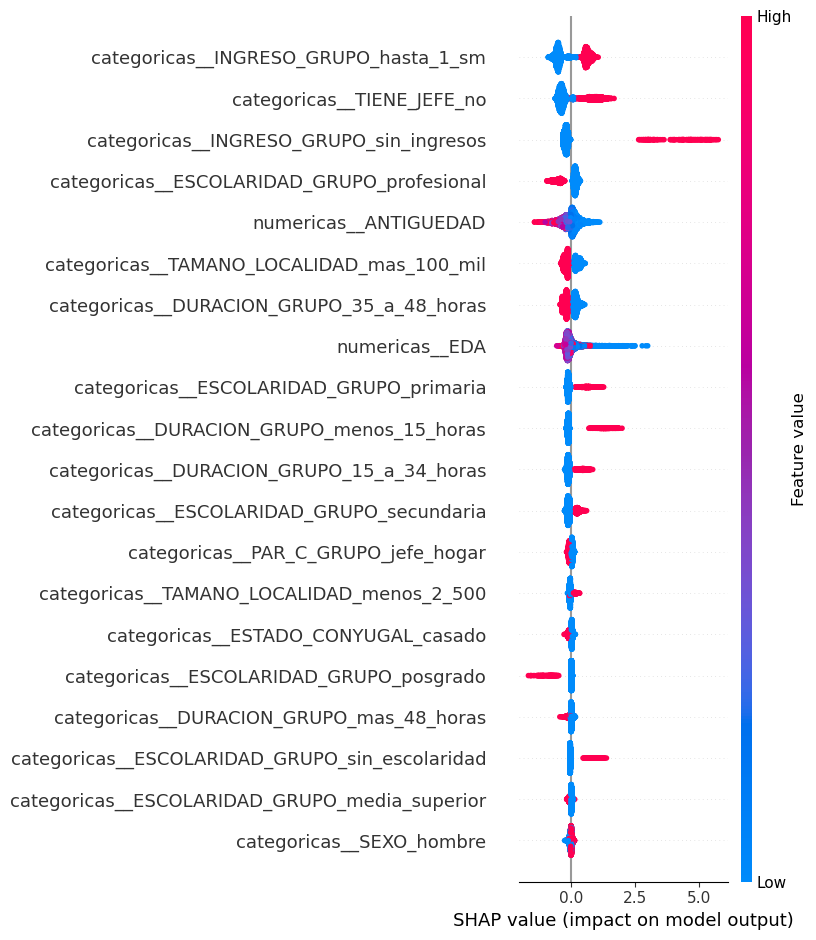

In [23]:
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=nombres_features,
    max_display=20
)

El gráfico SHAP global muestra que las predicciones del modelo están impulsadas principalmente por ingreso, condición de subordinación, escolaridad, duración de la jornada, edad y antigüedad. En general, menores ingresos, ausencia de jefe, menor escolaridad y jornadas reducidas desplazan la predicción hacia mayor riesgo de informalidad. Por el contrario, niveles educativos altos, mayor antigüedad y algunas características asociadas con empleos más estables tienden a reducir el riesgo estimado.

Ahora agruparemos los 82 SHAP transformados de vuelta a las 12 variables originales. Eso nos daría una importancia SHAP global comparable directamente con Permutation Importance.

In [24]:
variables_originales = variables_numericas + variables_categoricas

# DataFrame con SHAP de las 82 características transformadas
df_shap = pd.DataFrame(
    shap_values.values,
    columns=nombres_features
)

shap_agrupado = pd.DataFrame(index=df_shap.index)

for variable in variables_originales:

    if variable == "EDA":
        columnas = [
            c for c in nombres_features
            if c == "numericas__EDA"
        ]

    elif variable == "ANTIGUEDAD":
        columnas = [
            c for c in nombres_features
            if (
                c == "numericas__ANTIGUEDAD"
                or c == "numericas__missingindicator_ANTIGUEDAD"
            )
        ]

    else:
        prefijo = f"categoricas__{variable}_"
        columnas = [
            c for c in nombres_features
            if c.startswith(prefijo)
        ]

    shap_agrupado[variable] = df_shap[columnas].sum(axis=1)

Ahora calculamos la importancia global SHAP como el valor absoluto medio:

In [25]:
tabla_shap_global = (
    shap_agrupado
    .abs()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

tabla_shap_global.columns = [
    "variable",
    "media_abs_shap"
]

tabla_shap_global

,variable,media_abs_shap
0,INGRESO_GRUPO,0.774123
1,TIENE_JEFE,0.542378
2,ESCOLARIDAD_GRUPO,0.527181
3,DURACION_GRUPO,0.468217
4,TAMANO_LOCALIDAD,0.252150
5,ENTIDAD,0.250732
6,ANTIGUEDAD,0.250041
7,EDA,0.190734
8,PAR_C_GRUPO,0.069854
9,ESTADO_CONYUGAL,0.066672


Al agrupar los valores SHAP de las características derivadas mediante One-Hot Encoding, se obtiene una medida de importancia a nivel de las 12 variables originales. Los resultados confirman que INGRESO_GRUPO, TIENE_JEFE, ESCOLARIDAD_GRUPO y DURACION_GRUPO concentran la mayor influencia sobre las predicciones del modelo. Este patrón coincide con el obtenido mediante Permutation Importance, aportando evidencia consistente sobre cuáles son los principales predictores del riesgo estimado de informalidad. Las diferencias menores en el orden de las variables restantes son esperables, ya que ambas técnicas cuantifican la importancia desde perspectivas distintas.

Ahora estudiemos cómo cambian las predicciones según EDA y ANTIGUEDAD, y después interpretemos categorías concretas de ingreso, escolaridad, jornada y condición de jefe.

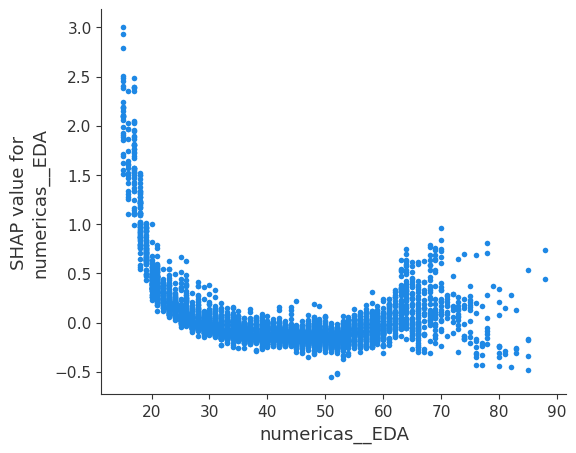

In [27]:
indice_eda = list(nombres_features).index("numericas__EDA")

shap.dependence_plot(
    indice_eda,
    shap_values.values,
    X_shap,
    feature_names=nombres_features,
    interaction_index=None
)

# plt.title("Efecto SHAP de la edad")
plt.show()


El gráfico de dependencia SHAP para EDA evidencia una relación no lineal con el riesgo estimado de informalidad. Las edades más jóvenes presentan contribuciones SHAP claramente positivas, especialmente por debajo de los 20 años. El efecto disminuye progresivamente durante la adultez y alcanza valores cercanos a cero o negativos en edades intermedias. A partir de aproximadamente los 60 años, la contribución vuelve a aumentar. Esto sugiere que el modelo identifica perfiles de mayor riesgo en los extremos de la distribución de edad.

Repitamos el análisis con ANTIGUEDAD

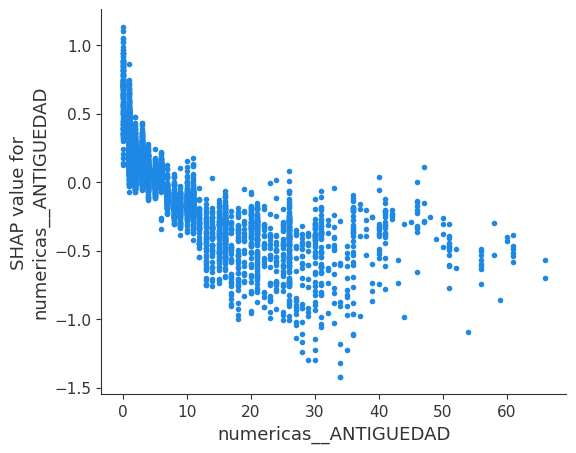

In [28]:
indice_antiguedad = list(nombres_features).index("numericas__ANTIGUEDAD")

shap.dependence_plot(
    indice_antiguedad,
    shap_values.values,
    X_shap,
    feature_names=nombres_features,
    interaction_index=None
)

# plt.title("Efecto SHAP de la edad")
plt.show()


Las antigüedades muy bajas presentan contribuciones SHAP positivas, indicando que una permanencia reciente en el empleo actual incrementa la probabilidad predicha de informalidad. Conforme aumenta la antigüedad, esta contribución disminuye y se vuelve mayoritariamente negativa, especialmente a partir de aproximadamente 8–10 años. Esto sugiere que el modelo asocia una mayor permanencia en el empleo con perfiles de menor riesgo estimado de informalidad

Primero recuperamos las observaciones originales correspondientes a la muestra SHAP:

In [29]:
X_shap_original = X_test.iloc[indices_shap].reset_index(drop=True)
pesos_shap = np.asarray(pesos_test)[indices_shap]

X_shap_original = X_test.iloc[indices_shap].reset_index(drop=True)
pesos_shap = np.asarray(pesos_test)[indices_shap]

In [30]:
df_ingreso_shap = pd.DataFrame({
    "categoria": X_shap_original["INGRESO_GRUPO"],
    "shap": shap_agrupado["INGRESO_GRUPO"],
    "peso": pesos_shap
})

tabla_ingreso_shap = (
    df_ingreso_shap
    .groupby("categoria")
    .apply(
        lambda x: pd.Series({
            "shap_medio": np.average(
                x["shap"],
                weights=x["peso"]
            ),
            "n": len(x)
        }),
        include_groups=False
    )
    .sort_values("shap_medio", ascending=False)
)

tabla_ingreso_shap

,shap_medio,n
categoria,,
sin_ingresos,4.048662,171.0
hasta_1_sm,0.518559,2350.0
no_especificado,-0.626212,484.0
mas_1_hasta_2_sm,-0.745068,1575.0
mas_2_hasta_3_sm,-1.071953,270.0
mas_3_hasta_5_sm,-1.238763,111.0
mas_5_sm,-1.423424,39.0


La categoría sin_ingresos presenta la mayor contribución positiva al riesgo estimado de informalidad, seguida de hasta_1_sm. En contraste, las categorías superiores a un salario mínimo muestran contribuciones negativas, y este efecto reductor se intensifica conforme aumenta el nivel de ingreso. Este patrón sugiere que el modelo utiliza el ingreso como una de las señales más importantes para diferenciar perfiles de mayor y menor riesgo de informalidad. La interpretación es predictiva y no causal.

Pasemos ahora con ESCOLARIDAD_GRUPO

In [31]:
df_ingreso_shap = pd.DataFrame({
    "categoria": X_shap_original["ESCOLARIDAD_GRUPO"],
    "shap": shap_agrupado["ESCOLARIDAD_GRUPO"],
    "peso": pesos_shap
})

tabla_ingreso_shap = (
    df_ingreso_shap
    .groupby("categoria")
    .apply(
        lambda x: pd.Series({
            "shap_medio": np.average(
                x["shap"],
                weights=x["peso"]
            ),
            "n": len(x)
        }),
        include_groups=False
    )
    .sort_values("shap_medio", ascending=False)
)

tabla_ingreso_shap

,shap_medio,n
categoria,,
sin_escolaridad,1.106456,132.0
primaria,0.888437,783.0
no_sabe,0.538280,9.0
secundaria,0.426723,1344.0
preescolar,0.081251,2.0
media_superior,-0.107718,1210.0
normal_tecnica,-0.249883,137.0
profesional,-0.741893,1255.0
posgrado,-1.068813,128.0


La ausencia de escolaridad y la educación primaria presentan las mayores contribuciones positivas al riesgo estimado de informalidad, mientras que la educación profesional y el posgrado desplazan las predicciones hacia menor riesgo. La educación media superior se sitúa aproximadamente en una zona de transición. Este resultado indica que la escolaridad constituye una señal relevante para el modelo y que su efecto predictivo cambia de forma ordenada entre niveles educativos.

Repitamos el análisis con DURACION_GRUPO

In [32]:
df_ingreso_shap = pd.DataFrame({
    "categoria": X_shap_original["DURACION_GRUPO"],
    "shap": shap_agrupado["DURACION_GRUPO"],
    "peso": pesos_shap
})

tabla_ingreso_shap = (
    df_ingreso_shap
    .groupby("categoria")
    .apply(
        lambda x: pd.Series({
            "shap_medio": np.average(
                x["shap"],
                weights=x["peso"]
            ),
            "n": len(x)
        }),
        include_groups=False
    )
    .sort_values("shap_medio", ascending=False)
)

tabla_ingreso_shap

,shap_medio,n
categoria,,
menos_15_horas,1.596056,335.0
no_especificado,0.780760,54.0
15_a_34_horas,0.630742,848.0
mas_48_horas,-0.135414,1140.0
35_a_48_horas,-0.396717,2466.0
ausente_con_vinculo,-0.404248,157.0


La categoría menos_15_horas presenta el efecto positivo más intenso, seguida de 15_a_34_horas. Por el contrario, las jornadas de 35_a_48_horas, mas_48_horas y la condición ausente_con_vinculo tienden a desplazar la predicción hacia menor riesgo de informalidad.

Ahora interpretemos TIENE_JEFE

In [33]:
df_ingreso_shap = pd.DataFrame({
    "categoria": X_shap_original["TIENE_JEFE"],
    "shap": shap_agrupado["TIENE_JEFE"],
    "peso": pesos_shap
})

tabla_ingreso_shap = (
    df_ingreso_shap
    .groupby("categoria")
    .apply(
        lambda x: pd.Series({
            "shap_medio": np.average(
                x["shap"],
                weights=x["peso"]
            ),
            "n": len(x)
        }),
        include_groups=False
    )
    .sort_values("shap_medio", ascending=False)
)

tabla_ingreso_shap

,shap_medio,n
categoria,,
no,0.916507,1351.0
si,-0.378911,3649.0


No tener jefe presenta una contribución positiva importante al riesgo estimado de informalidad, mientras que tener jefe desplaza la predicción hacia menor riesgo. Este comportamiento es consistente con los patrones observados durante el análisis exploratorio y confirma que la condición de subordinación constituye una de las señales más relevantes utilizadas por el modelo.

Analicemos ahora a la explicabilidad locas, es decir, seleccionar unas pocas personas del X_test y explicar por qué el modelo les asignó determinada probabilidad. Nos concentraremos en tres perfiles:
+ uno de riesgo alto
+ Uno cercano al riesgo medio
+ uno de riesgo bajo

In [35]:
probas_test = modelo_final.predict_proba(X_test)[:, 1]

df_perfiles = X_test.copy()
df_perfiles["prob_informalidad"] = probas_test

df_perfiles = df_perfiles.sort_values(
    "prob_informalidad",
    ascending=False
)

print("Riesgo alto:")
display(df_perfiles.head(1))

print("Riesgo medio:")
display(
    df_perfiles.iloc[
        [len(df_perfiles) // 2]
    ]
)

print("Riesgo bajo:")
display(df_perfiles.tail(1))

Riesgo alto:


,EDA,ANTIGUEDAD,PAR_C_GRUPO,ESCOLARIDAD_GRUPO,INGRESO_GRUPO,DURACION_GRUPO,TAMANO_LOCALIDAD,ESTADO_CONYUGAL,BUSQUEDA_OTRO_EMPLEO,TIENE_JEFE,SEXO,ENTIDAD,prob_informalidad
53863,15,1.0,otro_familiar,secundaria,sin_ingresos,menos_15_horas,menos_2_500,soltero,no_busco,si,mujer,Veracruz,0.999604


Riesgo medio:


,EDA,ANTIGUEDAD,PAR_C_GRUPO,ESCOLARIDAD_GRUPO,INGRESO_GRUPO,DURACION_GRUPO,TAMANO_LOCALIDAD,ESTADO_CONYUGAL,BUSQUEDA_OTRO_EMPLEO,TIENE_JEFE,SEXO,ENTIDAD,prob_informalidad
124808,57,6.0,jefe_hogar,profesional,mas_1_hasta_2_sm,mas_48_horas,mas_100_mil,separado,no_busco,no,hombre,Puebla,0.516068


Riesgo bajo:


,EDA,ANTIGUEDAD,PAR_C_GRUPO,ESCOLARIDAD_GRUPO,INGRESO_GRUPO,DURACION_GRUPO,TAMANO_LOCALIDAD,ESTADO_CONYUGAL,BUSQUEDA_OTRO_EMPLEO,TIENE_JEFE,SEXO,ENTIDAD,prob_informalidad
148710,52,31.0,pareja,profesional,mas_5_sm,ausente_con_vinculo,15_mil_a_99_999,casado,no_busco,si,mujer,Yucatán,0.010816


Calculemos SHAP específicamente para estas tres personas:

In [36]:
indices_perfiles = [53863, 124808, 148710]

X_perfiles = X_test.loc[indices_perfiles]

X_perfiles_transformado = pd.DataFrame(
    preprocesador_final.transform(X_perfiles),
    columns=nombres_features,
    index=indices_perfiles
)

shap_perfiles = explainer(X_perfiles_transformado)

El de perfil de riesgo alto:

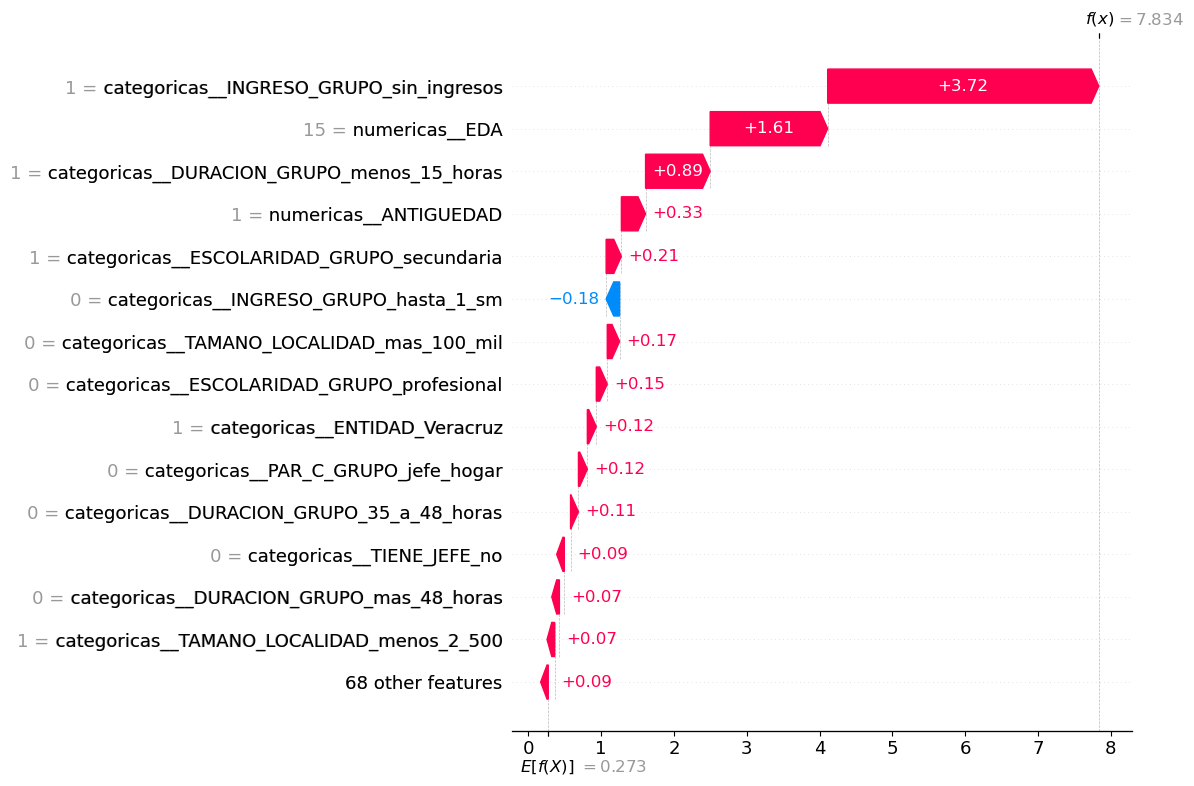

In [37]:
shap.plots.waterfall(
    shap_perfiles[0],
    max_display=15
)

La predicción está impulsada principalmente por la combinación de sin_ingresos, edad muy joven (15 años), jornada laboral de menos_15_horas y baja ANTIGUEDAD. Estas características empujan fuertemente la salida del modelo hacia mayor probabilidad de informalidad. También contribuyen, en menor medida, la escolaridad de nivel secundaria y algunas características territoriales. En conjunto, el modelo identifica un perfil laboral altamente precario y por ello asigna una probabilidad de informalidad cercana a 1.

Para el perfil de riesgo medio

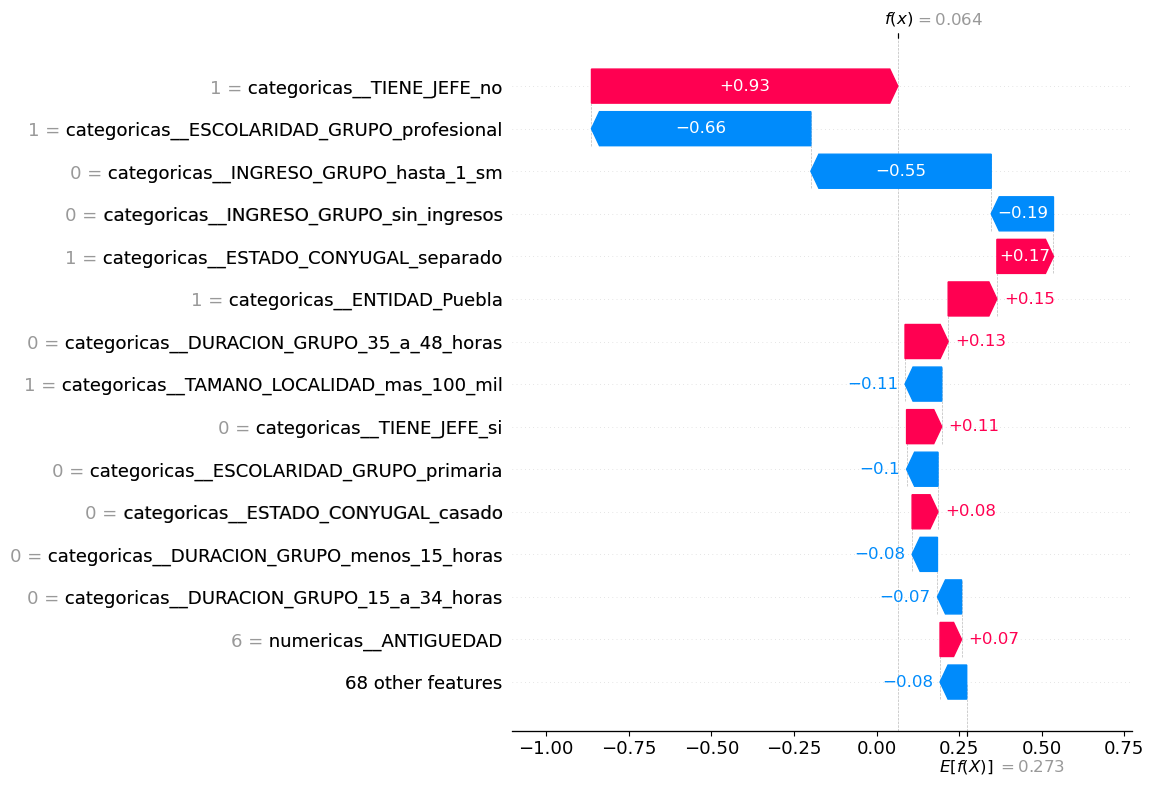

In [38]:
shap.plots.waterfall(
    shap_perfiles[1],
    max_display=15
)

La ausencia de jefe constituye el principal factor que incrementa el riesgo estimado, mientras que contar con educación profesional y un nivel de ingreso superior a las categorías de menor ingreso reducen sustancialmente la predicción. Otras características tienen efectos más moderados. La compensación entre estas contribuciones produce una probabilidad final cercana al 50% (51.6%), ilustrando cómo el modelo combina simultáneamente características asociadas con mayor y menor riesgo.

Pasemos a ver el perfil de riesgo bajo

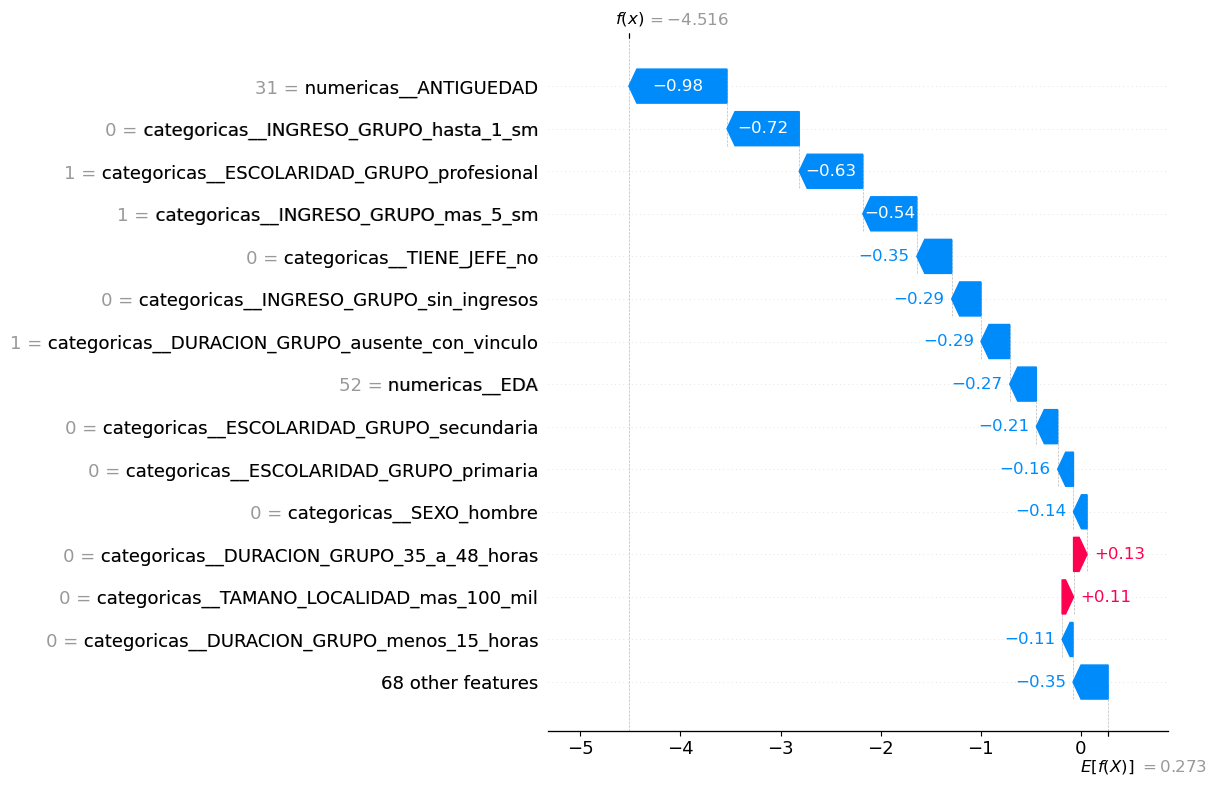

In [39]:
shap.plots.waterfall(
    shap_perfiles[-1],
    max_display=15
)

En este perfil destaca una antigüedad laboral elevada, educación profesional, ingresos superiores a cinco salarios mínimos y la existencia de una relación de subordinación. La edad de 52 años y otras características laborales también contribuyen a reducir el riesgo. La combinación de estos factores lleva al modelo a estimar una probabilidad de informalidad cercana al 1.1%.

**La fase de explicabilidad permitió identificar de forma consistente las variables que más influyen en las predicciones del modelo. Tanto Permutation Importance como SHAP señalaron a `INGRESO_GRUPO`, `TIENE_JEFE`, `ESCOLARIDAD_GRUPO` y `DURACION_GRUPO` como los principales predictores, mientras que `EDA` y `ANTIGUEDAD` mostraron relaciones no lineales relevantes.**

**El análisis SHAP también permitió interpretar la dirección de los efectos y explicar predicciones individuales de riesgo alto, medio y bajo. En conjunto, los resultados muestran que el modelo combina múltiples características laborales y sociodemográficas para estimar el riesgo de informalidad, en lugar de depender de una sola variable. Estas asociaciones deben entenderse exclusivamente en términos predictivos y no como relaciones causales.**

# Con esto terminamos el modelado, entrenamiento, evaluación y comparación de modelos
Pasaremos ahora a guardar el modelo, versiones del entorno y desarollar la estructura para su desspliegue en AWS.

In [ ]:
import joblib
import sys
import sklearn

# Guardar pipeline completo entrenado
joblib.dump(
    modelo_final,
    "/home/jeffrey/Documentos/Proyectos/enoe_informalidad/models/modelo_final.joblib"
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [43]:
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("joblib:", joblib.__version__)
print("shap:", shap.__version__)

Python: 3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]
scikit-learn: 1.7.2
pandas: 2.3.3
numpy: 2.2.5
joblib: 1.5.3
shap: 0.48.0


Verifiquemos que produce exactamente las mismas probabilidades que modelo_final

In [44]:
modelo_cargado = joblib.load(
    "/home/jeffrey/Documentos/Proyectos/enoe_informalidad/models/modelo_final.joblib"
)

proba_original = modelo_final.predict_proba(
    X_test.iloc[:10]
)[:, 1]

proba_cargado = modelo_cargado.predict_proba(
    X_test.iloc[:10]
)[:, 1]

print(proba_original)
print(proba_cargado)

print(
    "Predicciones idénticas:",
    np.allclose(proba_original, proba_cargado)
)

[0.98108761 0.11283033 0.76054862 0.10743089 0.43428672 0.62910552
 0.90882101 0.89511865 0.02842639 0.48195938]
[0.98108761 0.11283033 0.76054862 0.10743089 0.43428672 0.62910552
 0.90882101 0.89511865 0.02842639 0.48195938]
Predicciones idénticas: True
